In [ ]:
# !pip uninstall -y numpy
# !pip install --force-reinstall numpy==1.26.4
# !pip install -U tensorflow-text==2.15
# !pip install -U "tf-models-official==2.15.*"
# import os
# os.kill(os.getpid(), 9)

In [2]:
import os
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text
import pandas as pd
import seaborn as sn
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
os.environ['TF_USE_LEGACY_KERAS'] = '1'

In [3]:
df = pd.read_csv("15) spam.csv")
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.groupby('Category').describe()

Message                                                            \
           count unique                                                top   
Category                                                                     
ham         4825   4516                             Sorry, I'll call later   
spam         747    641  Please call our customer service representativ...   

               
         freq  
Category       
ham        30  
spam        4

In [5]:
df_spam = df[df['Category']=='spam']
df_ham = df[df['Category']=='ham']
df_spam_oversampled = resample(df_spam, replace=True,  n_samples=len(df_ham), random_state=1)
print(df_ham.shape, df_spam_oversampled.shape)
df = pd.concat([df_ham.sample(n=500, random_state=1), df_spam_oversampled.sample(n=500, random_state=1)])
df.shape

(4825, 2) (4825, 2)


(1000, 2)

In [6]:
df['spam']=df['Category'].apply(lambda x: 1 if x=='spam' else 0)
df.head()

,Category,Message,spam
2535,ham,Ok enjoy . R u there in home.,0
1213,ham,"Yo, the game almost over? Want to go to walmar...",0
522,ham,Shall i come to get pickle,0
5398,ham,Hi. Hope you had a good day. Have a better night.,0
700,ham,K..u also dont msg or reply to his msg..,0


In [7]:
x_train, x_test, y_train, y_test = train_test_split(df['Message'],df['spam'], stratify=df['spam'])

In [8]:
bert_preprocess = hub.KerasLayer("https://tfhub.dev/tensorflow/albert_en_preprocess/3")
bert_encoder = hub.KerasLayer("https://tfhub.dev/tensorflow/albert_en_base/3")

In [9]:
def get_sentence_embedding(sentences):
    preprocessed_text = bert_preprocess(sentences)
    return bert_encoder(preprocessed_text)['pooled_output']
outs = get_sentence_embedding([
    "Ocean", "Tree", "Mountain", "River", "Forest", "Lion", "Whale", "Eagle",
    "Panda", "Shark", "Joy", "Fear", "Peace", "Anger", "Love", "Paris", "Sahara",
    "Himalayas", "Amazon", "Antarctica", "Freedom", "Justice", "Eternity", "Chaos",
    "Harmony", "Book", "Phone", "Chair", "Car", "Clock"
])
for i in range(len(outs)):
  print(cosine_similarity([outs[5]],[outs[i]]))

[[0.9822142]]
[[0.26997417]]
[[0.2756037]]
[[0.943233]]
[[0.9376211]]
[[1.]]
[[0.27306864]]
[[0.9877296]]
[[0.92805815]]
[[0.9866447]]
[[0.2616146]]
[[0.26750284]]
[[0.9094242]]
[[0.26981232]]
[[0.26239872]]
[[0.8097359]]
[[0.9829092]]
[[0.8829398]]
[[0.26771173]]
[[0.9909344]]
[[0.26714993]]
[[0.27422714]]
[[0.26345456]]
[[0.27500978]]
[[0.91867244]]
[[0.26946762]]
[[0.26988292]]
[[0.26455167]]
[[0.27575842]]
[[0.26655963]]


In [17]:
text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name="text")
preprocessed_text = bert_preprocess(text_input)
outputs = bert_encoder(preprocessed_text)
nnl = tf.keras.layers.Dropout(0.1, name="dropout")(outputs['pooled_output'])
nnl = tf.keras.layers.Dense(1, activation='sigmoid', name="output")(nnl)
model = tf.keras.Model(inputs=[text_input], outputs=[nnl])
print(model.summary())
model.compile(optimizer='adam', loss='binary_crossentropy')
model.fit(x_train, y_train, epochs=1)

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 keras_layer (KerasLayer)    {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                                            

In [12]:
y_predicted = np.where(model.predict(x_test) > 0.5, 1, 0)

8/8 [==============================] - 103s 13s/step


In [13]:
cm = confusion_matrix(y_test, y_predicted)
cm

array([[ 68,  57],
       [  3, 122]])

Text(50.722222222222214, 0.5, 'Truth')

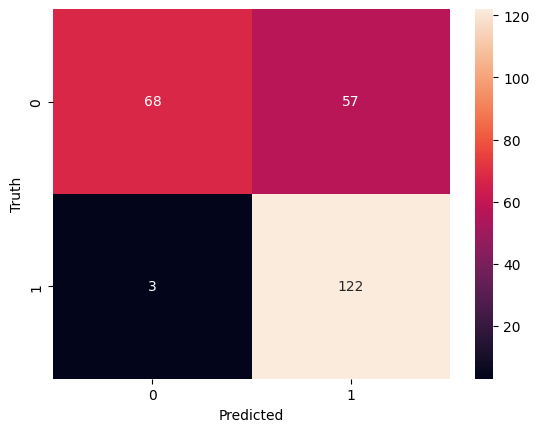

In [14]:
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [15]:
print(classification_report(y_test, y_predicted))

              precision    recall  f1-score   support

           0       0.96      0.54      0.69       125
           1       0.68      0.98      0.80       125

    accuracy                           0.76       250
   macro avg       0.82      0.76      0.75       250
weighted avg       0.82      0.76      0.75       250



In [16]:
reviews = [
    'Enter a chance to win $5000, hurry up, offer valid until march 31, 2021',
    'You are awarded a SiPix Digital Camera! call 09061221061 from landline. Delivery within 28days. T Cs Box177. M221BP. 2yr warranty. 150ppm. 16 . p pÂ£3.99',
    'it to 80488. Your 500 free text messages are valid until 31 December 2005.',
    'Hey Sam, Are you coming for a cricket game tomorrow',
    "Why don't you wait 'til at least wednesday to see if you get your ."
]
model.predict(reviews)

1/1 [==============================] - 2s 2s/step


array([[0.59349597],
       [0.7933705 ],
       [0.7085827 ],
       [0.45144916],
       [0.33051622]], dtype=float32)